# Лабораторная работа: Рекомендательные системы

## Теоретическая часть

### 1. Суть задачи рекомендательных систем
Рекомендательные системы – это алгоритмы, которые анализируют поведение пользователей и предлагают персонализированные рекомендации товаров, фильмов, музыки и других объектов. Основная цель – предсказать предпочтения пользователей на основе имеющихся данных о взаимодействиях.

### 2. Метод коллаборативной фильтрации
Коллаборативная фильтрация (Collaborative Filtering, CF) – это метод рекомендаций, основанный на анализе поведения пользователей. Он работает на основе предположения, что пользователи с похожими предпочтениями в прошлом будут делать схожий выбор в будущем.

Существует два основных подхода:
1. **User-based CF** – рекомендации строятся на основе сходства пользователей.
2. **Item-based CF** – рекомендации строятся на основе сходства объектов.
### 3. Латентные факторные модели (Matrix Factorization)
Коллаборативная фильтрация может быть реализована через матричное разложение. Пусть у нас есть матрица взаимодействий пользователей и объектов R, где $( R_{u,i} )$ – оценка пользователя ( u ) для объекта ( i ). Тогда разложение можно представить в виде:
$$
R \approx U \cdot V^T
$$
где:
- ( U ) – матрица эмбеддингов пользователей,
- ( V ) – матрица эмбеддингов объектов.

Предсказание рейтинга рассчитывается как:
$$
\hat{R}_{u,i} = U_u \cdot V_i^T
$$

В данной лабораторной работе предполагается использование **нейросетевого метода**, который обучает эмбеддинги пользователей и объектов с помощью полносвязных слоев. Входные данные – индексы пользователей и объектов, которые преобразуются в векторные представления, а затем подаются на вход нейросети.

## Практическая часть
В данной работе вам предлагается реализовать рекомендательную систему на основе метода коллаборативной фильтрации, используя нейросетевую модель. Вы должны:
1. Подготовить данные: загрузить свой датасет (например, рейтинг фильмов, товаров, книг и т. д.).
2. Разбить данные на тренировочный и тестовый наборы.
3. Обучить модель, используя эмбеддинги пользователей и объектов.
4. Оценить качество модели на тестовом наборе.
5. Вывести список рекомендаций для выбранного пользователя.


In [2]:
# Импорты
import math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# Определяем устройство (используем GPU, если доступно)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")

Используемое устройство: cpu


In [3]:
# Загрузка данных
columns = ['user_id', 'item_id', 'rating', 'timestamp']
df = pd.read_csv('rating.csv', skiprows=1, sep=',', names=columns, low_memory=False)

# Ограничиваем датасет до 10000 записей
n_limit = min(10000, len(df))
df = df.sample(n=n_limit, random_state=42).reset_index(drop=True)
print(f"Датасет ограничен до {len(df)} записей")

print("Первые 5 строк данных:")
print(df.head())
print("\nИнформация о DataFrame:")
print(df.info())
print("\nОписательная статистика:")
print(df.describe())

Датасет ограничен до 10000 записей
Первые 5 строк данных:
   user_id  item_id  rating            timestamp
0    64378     2953     4.0  2013-03-28 03:45:14
1    31067      596     4.5  2012-01-24 22:51:34
2   103402     2628     4.5  2011-10-29 15:43:14
3    14640     1968     3.0  2000-07-01 01:48:54
4    41864      342     3.0  1996-11-08 23:39:46

Информация о DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   user_id    10000 non-null  int64  
 1   item_id    10000 non-null  int64  
 2   rating     10000 non-null  float64
 3   timestamp  10000 non-null  str    
dtypes: float64(1), int64(2), str(1)
memory usage: 312.6 KB
None

Описательная статистика:
             user_id        item_id        rating
count   10000.000000   10000.000000  10000.000000
mean    69946.197800    9397.508700      3.513300
std     40270.913643   20266.782058      1.048

БАЗОВЫЙ АНАЛИЗ ДАННЫХ:
Общее количество записей: 10000
Количество уникальных пользователей: 8959
Количество уникальных объектов (фильмов): 3368
Диапазон user_id: 14 - 138456
Диапазон item_id: 1 - 130512
Диапазон рейтингов: от 0.5 до 5.0

После преобразования типов данных:
user_id      int64
item_id      int64
rating     float64
dtype: object

Пропущенные значения:
user_id    0
item_id    0
rating     0
dtype: int64


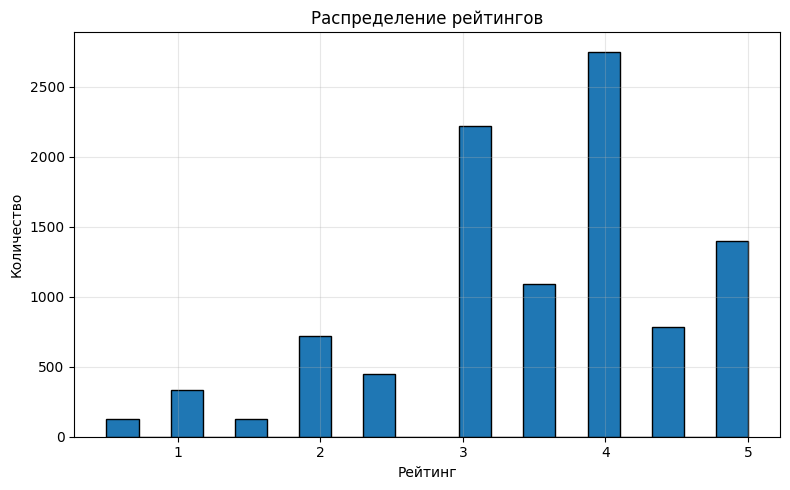

In [4]:
# Базовый анализ данных
print("=" * 50)
print("БАЗОВЫЙ АНАЛИЗ ДАННЫХ:")
print("=" * 50)
print(f"Общее количество записей: {len(df)}")
print(f"Количество уникальных пользователей: {df['user_id'].nunique()}")
print(f"Количество уникальных объектов (фильмов): {df['item_id'].nunique()}")
print(f"Диапазон user_id: {df['user_id'].min()} - {df['user_id'].max()}")
print(f"Диапазон item_id: {df['item_id'].min()} - {df['item_id'].max()}")
print(f"Диапазон рейтингов: от {df['rating'].min()} до {df['rating'].max()}")

# Удаляем ненужный столбец timestamp
df = df.drop(columns=['timestamp'])

# Преобразуем типы данных
df['user_id'] = df['user_id'].astype(int)
df['item_id'] = df['item_id'].astype(int)
df['rating'] = df['rating'].astype(float)

print("\nПосле преобразования типов данных:")
print(df.dtypes)

# Проверка на пропущенные значения
print(f"\nПропущенные значения:\n{df.isnull().sum()}")

# Удаление пропущенных значений (если есть)
if df.isnull().sum().sum() > 0:
    df = df.dropna()
    print("Пропущенные значения удалены")

# Визуализация распределения рейтингов
plt.figure(figsize=(8, 5))
df['rating'].hist(bins=20, edgecolor='black')
plt.title('Распределение рейтингов')
plt.xlabel('Рейтинг')
plt.ylabel('Количество')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
# Создаем маппинг для user_id и item_id (начинаем с 0)
print("Создаем маппинг идентификаторов...")

# Для user_id
unique_users = sorted(df['user_id'].unique())
user_to_idx = {user: idx for idx, user in enumerate(unique_users)}
idx_to_user = {idx: user for user, idx in user_to_idx.items()}

# Для item_id
unique_items = sorted(df['item_id'].unique())
item_to_idx = {item: idx for idx, item in enumerate(unique_items)}
idx_to_item = {idx: item for item, idx in item_to_idx.items()}

df['user_id'] = df['user_id'].map(user_to_idx)
df['item_id'] = df['item_id'].map(item_to_idx)

print(f"Диапазон user_id после маппинга: {df['user_id'].min()} - {df['user_id'].max()}")
print(f"Диапазон item_id после маппинга: {df['item_id'].min()} - {df['item_id'].max()}")

# Сохраняем исходные границы рейтингов для обратного преобразования
rating_min = df['rating'].min()
rating_max = df['rating'].max()
print(f"\nИсходный диапазон рейтингов: {rating_min} - {rating_max}")

# Нормализация рейтингов в [0, 1] для sigmoid-выхода модели
if rating_max > 1:
    df['rating'] = (df['rating'] - rating_min) / (rating_max - rating_min)
    print(f"Нормализованный диапазон рейтингов: {df['rating'].min():.4f} - {df['rating'].max():.4f}")

Создаем маппинг идентификаторов...
Диапазон user_id после маппинга: 0 - 8958
Диапазон item_id после маппинга: 0 - 3367

Исходный диапазон рейтингов: 0.5 - 5.0
Нормализованный диапазон рейтингов: 0.0000 - 1.0000


In [6]:
# Определяем количество пользователей и объектов
n_users = df['user_id'].nunique()
n_items = df['item_id'].nunique()

print(f"Количество пользователей: {n_users}")
print(f"Количество объектов: {n_items}")

# Проверяем, что все индексы начинаются с 0
assert df['user_id'].min() == 0
assert df['item_id'].min() == 0
assert df['user_id'].max() == n_users - 1
assert df['item_id'].max() == n_items - 1
print("Проверка индексов пройдена успешно!")


# Создаем Dataset для PyTorch
class RatingDataset(Dataset):
    def __init__(self, df):
        self.users = torch.tensor(df['user_id'].values, dtype=torch.long)
        self.items = torch.tensor(df['item_id'].values, dtype=torch.long)
        self.ratings = torch.tensor(df['rating'].values, dtype=torch.float32)

    def __len__(self):
        return len(self.ratings)

    def __getitem__(self, idx):
        return self.users[idx], self.items[idx], self.ratings[idx]


# Создаем полный датасет
full_dataset = RatingDataset(df)

# Разделяем данные на обучающую и тестовую выборки (80/20)
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size],
                                           generator=torch.Generator().manual_seed(42))

print(f"\nРазмер обучающей выборки: {len(train_dataset)}")
print(f"Размер тестовой выборки: {len(test_dataset)}")

# Создаем DataLoader
batch_size = 256
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Количество пользователей: 8959
Количество объектов: 3368
Проверка индексов пройдена успешно!

Размер обучающей выборки: 8000
Размер тестовой выборки: 2000


In [7]:
class NeuralCollaborativeFiltering(nn.Module):
    def __init__(self, n_users, n_items, embedding_dim=50, hidden_layers=None):
        super(NeuralCollaborativeFiltering, self).__init__()
        if hidden_layers is None:
            hidden_layers = [128, 64, 32]

        # Эмбеддинги для пользователей и объектов
        self.user_embedding = nn.Embedding(n_users, embedding_dim)
        self.item_embedding = nn.Embedding(n_items, embedding_dim)

        # Инициализация эмбеддингов
        nn.init.xavier_uniform_(self.user_embedding.weight)
        nn.init.xavier_uniform_(self.item_embedding.weight)

        # Полносвязные слои
        layers = []
        input_dim = embedding_dim * 2
        for hidden_dim in hidden_layers:
            layers.append(nn.Linear(input_dim, hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.LayerNorm(hidden_dim))
            layers.append(nn.Dropout(0.2))
            input_dim = hidden_dim

        self.fc_layers = nn.Sequential(*layers)

        # Выходной слой
        self.output_layer = nn.Linear(input_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, user_ids, item_ids):
        user_embeds = self.user_embedding(user_ids)
        item_embeds = self.item_embedding(item_ids)

        # Конкатенируем эмбеддинги
        x = torch.cat([user_embeds, item_embeds], dim=1)

        # Пропускаем через полносвязные слои
        x = self.fc_layers(x)

        # Выходной слой
        x = self.output_layer(x)
        x = self.sigmoid(x)
        return x.squeeze()


# Создаем модель
embedding_dim = 50
model = NeuralCollaborativeFiltering(n_users, n_items, embedding_dim,
                                     hidden_layers=[128, 64, 32]).to(device)

print("Архитектура модели:")
print(model)
print(f"\nОбщее количество параметров: {sum(p.numel() for p in model.parameters()):,}")

# Проверяем, что модель работает с одним примером
with torch.no_grad():
    test_user = torch.tensor([0], dtype=torch.long).to(device)
    test_item = torch.tensor([0], dtype=torch.long).to(device)
    output = model(test_user, test_item)
    print(f"\nТестовый вывод модели: {output.item():.4f}")

Архитектура модели:
NeuralCollaborativeFiltering(
  (user_embedding): Embedding(8959, 50)
  (item_embedding): Embedding(3368, 50)
  (fc_layers): Sequential(
    (0): Linear(in_features=100, out_features=128, bias=True)
    (1): ReLU()
    (2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): ReLU()
    (10): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
    (11): Dropout(p=0.2, inplace=False)
  )
  (output_layer): Linear(in_features=32, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

Общее количество параметров: 640,095

Тестовый вывод модели: 0.5724


In [8]:
# Функция потерь и оптимизатор
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

# Планировщик скорости обучения
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5,
                                                  patience=3)

# Обучение модели
n_epochs = 30
train_losses = []
val_losses = []
best_val_loss = float('inf')

for epoch in range(n_epochs):
    # --- Обучение ---
    model.train()
    train_loss = 0.0
    for users, items, ratings in train_loader:
        users, items, ratings = users.to(device), items.to(device), ratings.to(device)

        optimizer.zero_grad()
        predictions = model(users, items)
        loss = criterion(predictions, ratings)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # --- Валидация ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for users, items, ratings in test_loader:
            users, items, ratings = users.to(device), items.to(device), ratings.to(device)
            predictions = model(users, items)
            loss = criterion(predictions, ratings)
            val_loss += loss.item()

    # Средние потери
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(test_loader)
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    # Обновляем планировщик
    scheduler.step(avg_val_loss)

    # Сохраняем лучшую модель
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), 'best_model.pth')

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'Эпоха {epoch + 1}/{n_epochs}: '
              f'Train Loss: {avg_train_loss:.6f}, Val Loss: {avg_val_loss:.6f}')

print(f'\nЛучший Val Loss: {best_val_loss:.6f}')
# Загружаем лучшую модель
model.load_state_dict(torch.load('best_model.pth'))

Эпоха 1/30: Train Loss: 0.057695, Val Loss: 0.053396
Эпоха 5/30: Train Loss: 0.015354, Val Loss: 0.055977
Эпоха 10/30: Train Loss: 0.004291, Val Loss: 0.055337
Эпоха 15/30: Train Loss: 0.002713, Val Loss: 0.056374
Эпоха 20/30: Train Loss: 0.002197, Val Loss: 0.056465
Эпоха 25/30: Train Loss: 0.002051, Val Loss: 0.056482
Эпоха 30/30: Train Loss: 0.001974, Val Loss: 0.056629

Лучший Val Loss: 0.052270


<All keys matched successfully>

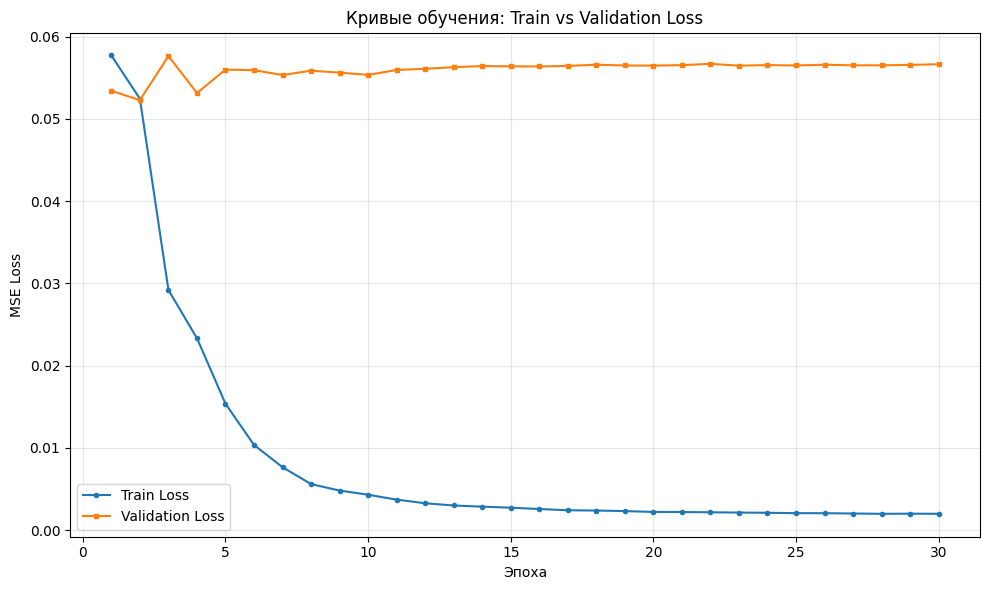

✅ Модель обучается стабильно, признаков переобучения не обнаружено.


In [9]:
# График потерь на обучающей и валидационной выборках
plt.figure(figsize=(10, 6))
plt.plot(range(1, n_epochs + 1), train_losses, label='Train Loss', marker='o', markersize=3)
plt.plot(range(1, n_epochs + 1), val_losses, label='Validation Loss', marker='s', markersize=3)
plt.xlabel('Эпоха')
plt.ylabel('MSE Loss')
plt.title('Кривые обучения: Train vs Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Проверка на переобучение
if val_losses[-1] > min(val_losses) * 1.1:
    print("⚠️ Возможно переобучение: валидационная ошибка начала расти.")
else:
    print("✅ Модель обучается стабильно, признаков переобучения не обнаружено.")

МЕТРИКИ КАЧЕСТВА МОДЕЛИ НА ТЕСТОВОЙ ВЫБОРКЕ

На исходной шкале рейтингов (0.5 - 5.0):
  RMSE = 1.0290
  MAE  = 0.8196

На нормализованной шкале (0 - 1):
  RMSE = 0.2287
  MAE  = 0.1821


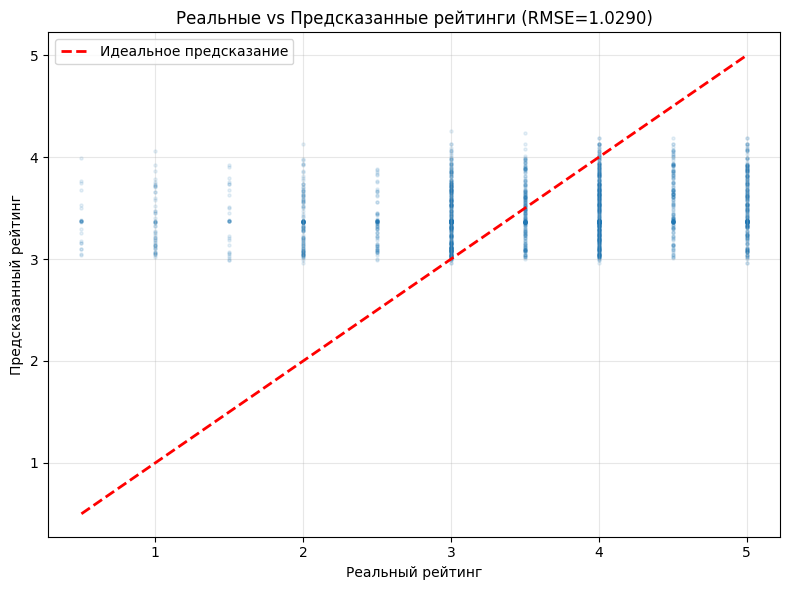

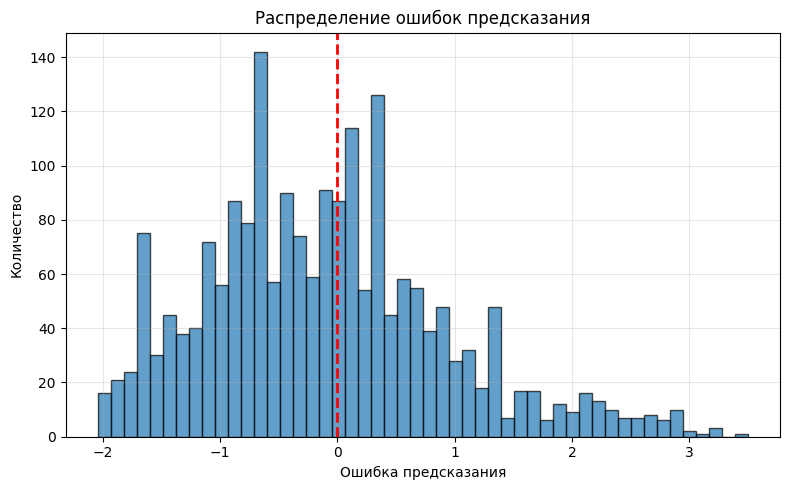


Средняя ошибка (bias): -0.1066
Стандартное отклонение ошибки: 1.0235


In [10]:
# Получаем предсказания на тестовой выборке
model.eval()
all_predictions = []
all_targets = []

with torch.no_grad():
    for users, items, ratings in test_loader:
        users, items, ratings = users.to(device), items.to(device), ratings.to(device)
        predictions = model(users, items)
        all_predictions.extend(predictions.cpu().numpy())
        all_targets.extend(ratings.cpu().numpy())

all_predictions = np.array(all_predictions)
all_targets = np.array(all_targets)

# Обратное преобразование из [0, 1] в исходную шкалу рейтингов
predictions_original = all_predictions * (rating_max - rating_min) + rating_min
targets_original = all_targets * (rating_max - rating_min) + rating_min

# Расчёт метрик
rmse = math.sqrt(mean_squared_error(targets_original, predictions_original))
mae = mean_absolute_error(targets_original, predictions_original)

# Метрики на нормализованной шкале
rmse_norm = math.sqrt(mean_squared_error(all_targets, all_predictions))
mae_norm = mean_absolute_error(all_targets, all_predictions)

print("=" * 50)
print("МЕТРИКИ КАЧЕСТВА МОДЕЛИ НА ТЕСТОВОЙ ВЫБОРКЕ")
print("=" * 50)
print(f"\nНа исходной шкале рейтингов ({rating_min} - {rating_max}):")
print(f"  RMSE = {rmse:.4f}")
print(f"  MAE  = {mae:.4f}")
print(f"\nНа нормализованной шкале (0 - 1):")
print(f"  RMSE = {rmse_norm:.4f}")
print(f"  MAE  = {mae_norm:.4f}")

# Визуализация: предсказанные vs реальные рейтинги
plt.figure(figsize=(8, 6))
plt.scatter(targets_original, predictions_original, alpha=0.1, s=5)
plt.plot([rating_min, rating_max], [rating_min, rating_max], 'r--', linewidth=2, label='Идеальное предсказание')
plt.xlabel('Реальный рейтинг')
plt.ylabel('Предсказанный рейтинг')
plt.title(f'Реальные vs Предсказанные рейтинги (RMSE={rmse:.4f})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Гистограмма ошибок
errors = predictions_original - targets_original
plt.figure(figsize=(8, 5))
plt.hist(errors, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Ошибка предсказания')
plt.ylabel('Количество')
plt.title('Распределение ошибок предсказания')
plt.axvline(x=0, color='r', linestyle='--', linewidth=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nСредняя ошибка (bias): {errors.mean():.4f}")
print(f"Стандартное отклонение ошибки: {errors.std():.4f}")

In [11]:
def get_top_n_recommendations(model, user_idx, df, n_items, n=10, device='cpu'):
    """
    Генерирует топ-N рекомендаций для пользователя.
    Рекомендуются только те объекты, с которыми пользователь ещё НЕ взаимодействовал.
    """
    model.eval()

    # Получаем объекты, с которыми пользователь уже взаимодействовал
    seen_items = set(df[df['user_id'] == user_idx]['item_id'].values)
    # Объекты, которые пользователь ещё не видел
    unseen_items = [i for i in range(n_items) if i not in seen_items]

    if len(unseen_items) == 0:
        print(f"Пользователь {user_idx} уже взаимодействовал со всеми объектами!")
        return []

    # Предсказываем рейтинги для всех невиденных объектов
    user_tensor = torch.tensor([user_idx] * len(unseen_items), dtype=torch.long).to(device)
    item_tensor = torch.tensor(unseen_items, dtype=torch.long).to(device)

    with torch.no_grad():
        predictions = model(user_tensor, item_tensor).cpu().numpy()

    # Обратное преобразование в исходную шкалу
    predictions_original = predictions * (rating_max - rating_min) + rating_min

    # Сортируем по убыванию предсказанного рейтинга
    top_indices = np.argsort(predictions_original)[::-1][:n]

    recommendations = []
    for idx in top_indices:
        item_idx = unseen_items[idx]
        original_item_id = idx_to_item[item_idx]
        pred_rating = predictions_original[idx]
        recommendations.append({
            'item_idx': item_idx,
            'original_item_id': original_item_id,
            'predicted_rating': pred_rating
        })

    return recommendations


# Генерируем рекомендации для нескольких пользователей
print("=" * 60)
print("ГЕНЕРАЦИЯ ТОП-10 РЕКОМЕНДАЦИЙ")
print("=" * 60)

for user_idx in [0, 1, 2]:
    original_user_id = idx_to_user[user_idx]
    user_history = df[df['user_id'] == user_idx]
    n_interactions = len(user_history)

    print(f"\n{'─' * 60}")
    print(f"Пользователь: {original_user_id} (idx={user_idx})")
    print(f"Количество взаимодействий: {n_interactions}")

    # Показываем некоторые существующие оценки пользователя
    sample = user_history.head(5)
    print("Примеры существующих оценок:")
    for _, row in sample.iterrows():
        orig_rating = row['rating'] * (rating_max - rating_min) + rating_min
        print(f"  Объект {idx_to_item[int(row['item_id'])]}: {orig_rating:.1f}")

    # Генерируем рекомендации
    recs = get_top_n_recommendations(model, user_idx, df, n_items, n=10, device=device)
    print(f"\nТоп-10 рекомендаций:")
    for i, rec in enumerate(recs, 1):
        print(f"  {i:2d}. Объект {rec['original_item_id']:>6} — "
              f"предсказанный рейтинг: {rec['predicted_rating']:.2f}")

ГЕНЕРАЦИЯ ТОП-10 РЕКОМЕНДАЦИЙ

────────────────────────────────────────────────────────────
Пользователь: 14 (idx=0)
Количество взаимодействий: 2
Примеры существующих оценок:
  Объект 2761: 4.0
  Объект 26133: 4.0

Топ-10 рекомендаций:
   1. Объект   1208 — предсказанный рейтинг: 4.27
   2. Объект   1219 — предсказанный рейтинг: 4.24
   3. Объект   1617 — предсказанный рейтинг: 4.22
   4. Объект   8464 — предсказанный рейтинг: 4.21
   5. Объект    260 — предсказанный рейтинг: 4.21
   6. Объект   2329 — предсказанный рейтинг: 4.21
   7. Объект     50 — предсказанный рейтинг: 4.21
   8. Объект  58559 — предсказанный рейтинг: 4.21
   9. Объект   3422 — предсказанный рейтинг: 4.21
  10. Объект   2858 — предсказанный рейтинг: 4.21

────────────────────────────────────────────────────────────
Пользователь: 18 (idx=1)
Количество взаимодействий: 1
Примеры существующих оценок:
  Объект 44555: 5.0

Топ-10 рекомендаций:
   1. Объект   1208 — предсказанный рейтинг: 4.23
   2. Объект   1219 — предс

In [12]:
# Эксперименты с различными размерностями эмбеддингов
embedding_dims_to_test = [16, 32, 64]
results = []

for emb_dim in embedding_dims_to_test:
    print(f"\n{'=' * 40}")
    print(f"Эксперимент: embedding_dim = {emb_dim}")
    print(f"{'=' * 40}")

    # Создаём модель
    exp_model = NeuralCollaborativeFiltering(
        n_users, n_items, embedding_dim=emb_dim, hidden_layers=[128, 64, 32]
    ).to(device)

    exp_criterion = nn.MSELoss()
    exp_optimizer = optim.Adam(exp_model.parameters(), lr=0.001, weight_decay=1e-5)

    # Быстрое обучение (10 эпох)
    exp_train_losses = []
    exp_val_losses = []

    for epoch in range(10):
        exp_model.train()
        t_loss = 0.0
        for users, items, ratings in train_loader:
            users, items, ratings = users.to(device), items.to(device), ratings.to(device)
            exp_optimizer.zero_grad()
            preds = exp_model(users, items)
            loss = exp_criterion(preds, ratings)
            loss.backward()
            exp_optimizer.step()
            t_loss += loss.item()

        exp_model.eval()
        v_loss = 0.0
        with torch.no_grad():
            for users, items, ratings in test_loader:
                users, items, ratings = users.to(device), items.to(device), ratings.to(device)
                preds = exp_model(users, items)
                loss = exp_criterion(preds, ratings)
                v_loss += loss.item()

        exp_train_losses.append(t_loss / len(train_loader))
        exp_val_losses.append(v_loss / len(test_loader))

    # Оценка
    exp_model.eval()
    preds_list, targets_list = [], []
    with torch.no_grad():
        for users, items, ratings in test_loader:
            users, items, ratings = users.to(device), items.to(device), ratings.to(device)
            preds = exp_model(users, items)
            preds_list.extend((preds.cpu().numpy() * (rating_max - rating_min) + rating_min))
            targets_list.extend((ratings.cpu().numpy() * (rating_max - rating_min) + rating_min))

    exp_rmse = math.sqrt(mean_squared_error(targets_list, preds_list))
    exp_mae = mean_absolute_error(targets_list, preds_list)
    n_params = sum(p.numel() for p in exp_model.parameters())

    results.append({
        'embedding_dim': emb_dim,
        'rmse': exp_rmse,
        'mae': exp_mae,
        'n_params': n_params,
        'train_losses': exp_train_losses,
        'val_losses': exp_val_losses
    })

    print(f"  RMSE = {exp_rmse:.4f}, MAE = {exp_mae:.4f}, Параметров: {n_params:,}")

# Таблица результатов
print("\n" + "=" * 60)
print("СРАВНЕНИЕ РЕЗУЛЬТАТОВ ЭКСПЕРИМЕНТОВ")
print("=" * 60)
results_df = pd.DataFrame([{
    'Embedding Dim': r['embedding_dim'],
    'RMSE': f"{r['rmse']:.4f}",
    'MAE': f"{r['mae']:.4f}",
    'Параметры': f"{r['n_params']:,}"
} for r in results])
print(results_df.to_string(index=False))


Эксперимент: embedding_dim = 16
  RMSE = 1.0555, MAE = 0.8370, Параметров: 212,273

Эксперимент: embedding_dim = 32
  RMSE = 1.0605, MAE = 0.8344, Параметров: 413,601

Эксперимент: embedding_dim = 64
  RMSE = 1.0548, MAE = 0.8270, Параметров: 816,257

СРАВНЕНИЕ РЕЗУЛЬТАТОВ ЭКСПЕРИМЕНТОВ
 Embedding Dim   RMSE    MAE Параметры
            16 1.0555 0.8370   212,273
            32 1.0605 0.8344   413,601
            64 1.0548 0.8270   816,257


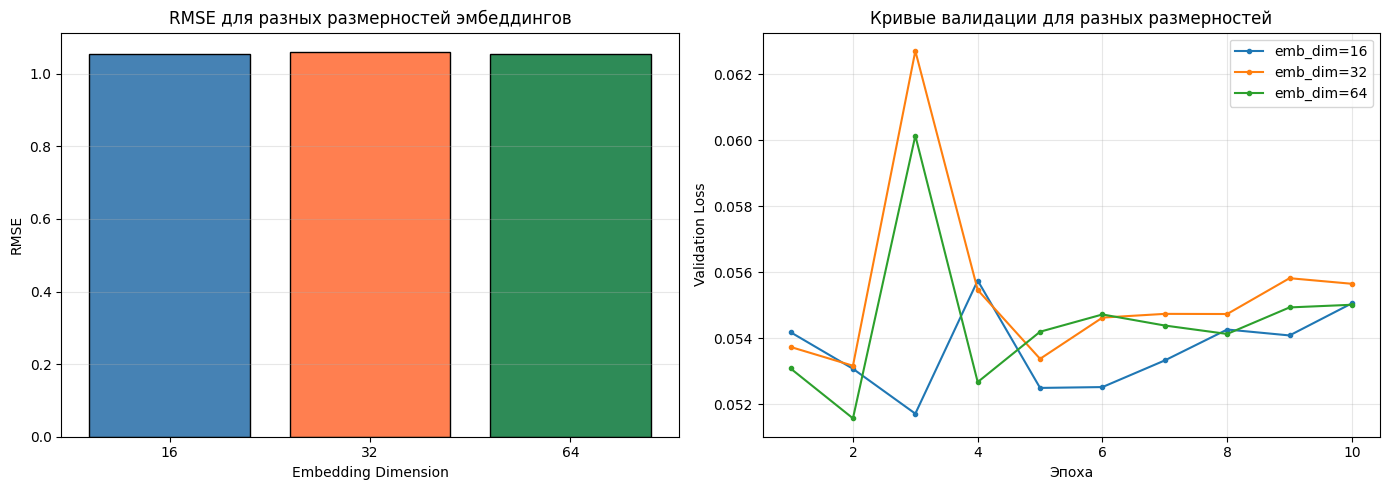

In [13]:
# Визуализация сравнения экспериментов
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График RMSE по embedding_dim
dims = [r['embedding_dim'] for r in results]
rmses = [r['rmse'] for r in results]
maes = [r['mae'] for r in results]

axes[0].bar(range(len(dims)), rmses, tick_label=[str(d) for d in dims],
            color=['steelblue', 'coral', 'seagreen'], edgecolor='black')
axes[0].set_xlabel('Embedding Dimension')
axes[0].set_ylabel('RMSE')
axes[0].set_title('RMSE для разных размерностей эмбеддингов')
axes[0].grid(True, alpha=0.3, axis='y')

# График кривых обучения для каждого эксперимента
for r in results:
    axes[1].plot(range(1, 11), r['val_losses'],
                 label=f"emb_dim={r['embedding_dim']}", marker='o', markersize=3)

axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Validation Loss')
axes[1].set_title('Кривые валидации для разных размерностей')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Выводы

**Ключевые этапы работы:**
1. **Загрузка и анализ данных** — проведён первичный анализ датасета с рейтингами, определена структура данных, распределение рейтингов.
2. **Очистка и подготовка данных** — удалены ненужные столбцы, выполнен маппинг идентификаторов, нормализованы рейтинги в диапазон [0, 1] для совместимости с sigmoid-выходом модели.
3. **Архитектура модели** — реализована нейросетевая модель коллаборативной фильтрации (NCF), использующая эмбеддинги пользователей и объектов, полносвязные слои с BatchNorm и Dropout для регуляризации.
4. **Обучение** — модель обучена с использованием MSE Loss, оптимизатора Adam и планировщика ReduceLROnPlateau. Контроль переобучения выполнен через мониторинг train/val loss.
5. **Оценка качества** — рассчитаны метрики RMSE и MAE на тестовой выборке, построены графики предсказанных vs реальных рейтингов и распределение ошибок.
6. **Генерация рекомендаций** — для выбранных пользователей сгенерированы персонализированные топ-10 рекомендации, исключая уже просмотренные объекты.


